<a href="https://colab.research.google.com/github/skr2rathishan-oss/AI-ML--Projects/blob/main/Titanic_Ship_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#29.09.2026 - Lecturer 03

In [1]:
!pip -q install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('pandas:', pd.__version__, 'numpy:', np.__version__)

pandas: 2.2.3 numpy: 2.1.3


In [4]:
df =sns.load_dataset("titanic")
print("Shape(rows,columns) :",df.shape)
df.head()

Shape(rows,columns) : (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print(df["survived"].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


<Axes: xlabel='survived', ylabel='count'>

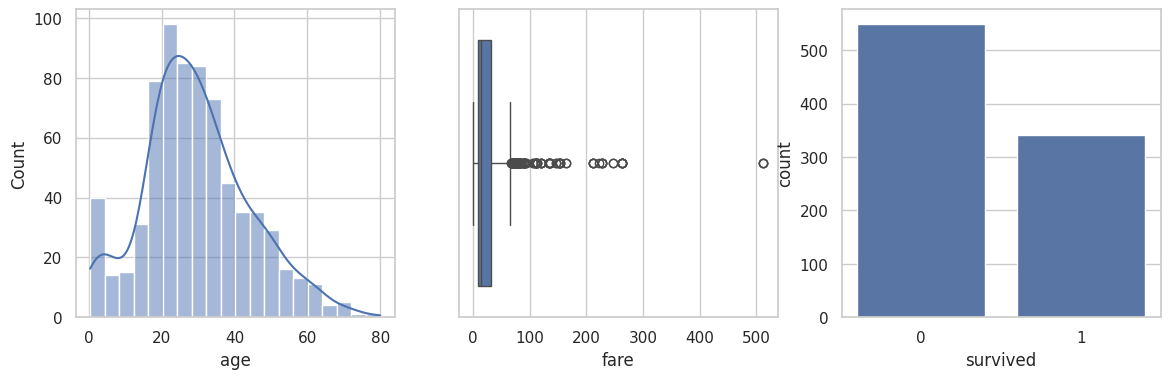

In [13]:
fig,ax=plt.subplots(1,3,figsize=(14,4))
sns.histplot(df["age"],kde=True,ax=ax[0])
sns.boxplot(x=df["fare"],ax=ax[1])
sns.countplot(x="survived",data=df,ax=ax[2])

In [14]:
print("duplicate rows: ", df.duplicated().sum())
df=df.drop_duplicates()
print(df.shape)

duplicate rows:  107
(784, 15)


In [20]:
print(df["survived"].value_counts(normalize=True))

survived
0    0.58801
1    0.41199
Name: proportion, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

x_raw=df.drop(columns=["survived"])
y=df["survived"]

x_train_raw,x_test_raw,y_train,y_test=train_test_split(x_raw,y,test_size=0.25,stratify=y,random_state=42)
print(x_train_raw.shape,x_test_raw.shape)

print(y_train.mean().round(3),y_test.mean().round(3))


(588, 14) (196, 14)
0.412 0.413


In [25]:
miss_frac = x_train_raw.isna().mean().sort_values(ascending=False)
print(miss_frac.head(6))

DROP_ALWAYS = ["alive", "class", "who", "adult_male", "embark_town", "alone"]
DROP_TOO_SPARSE = miss_frac[miss_frac > 0.5].index.tolist()   # e.g. 'deck' — computed on TRAIN only
print("dropping (too sparse, >50% missing in train):", DROP_TOO_SPARSE)

feats = [c for c in x_train_raw.columns if c not in DROP_ALWAYS + DROP_TOO_SPARSE]
print("features used:", feats)

x_train = x_train_raw[feats].copy()
x_test  = x_test_raw[feats].copy()

deck           0.738095
age            0.136054
embarked       0.003401
embark_town    0.003401
sex            0.000000
pclass         0.000000
dtype: float64
dropping (too sparse, >50% missing in train): ['deck']
features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [26]:
print(x_train.isna().mean().round(3))

pclass      0.000
sex         0.000
age         0.136
sibsp       0.000
parch       0.000
fare        0.000
embarked    0.003
dtype: float64


In [27]:
print("rows kept if we dropna :", len(x_train.dropna()),"of",len(x_train))

rows kept if we dropna : 506 of 588


In [28]:
from sklearn.impute import SimpleImputer, KNNImputer

Xtr, Xte = x_train.copy(), x_test.copy()

#median_age = Xtr['age'].median()
#Xtr[["age"]] = Xtr[["age"]].fillna(median_age)
#Xte[["age"]] = Xte[["age"]].fillna(median_age)

age_imp = SimpleImputer(strategy="median")
Xtr[["age"]] = age_imp.fit_transform(Xtr[["age"]])
Xte[["age"]] = age_imp.transform(Xte[["age"]])

emb_imp = SimpleImputer(strategy="most_frequent")
Xtr[["embarked"]] = emb_imp.fit_transform(Xtr[["embarked"]])
Xte[["embarked"]] = emb_imp.transform(Xte[["embarked"]])

print('Training median age:', age_imp.statistics_[0])
print('Training mode of embarked:', emb_imp.statistics_[0])
print('Missing after imputation:', Xtr.isna().sum().sum(), Xte.isna().sum().sum())

Training median age: 28.0
Training mode of embarked: S
Missing after imputation: 0 0


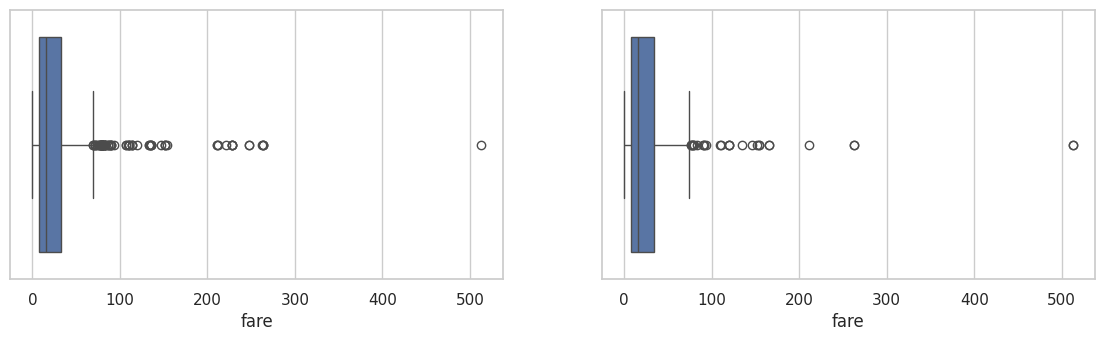

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
sns.boxplot(x=Xtr["fare"], ax=ax[0])
sns.boxplot(x=Xte["fare"], ax=ax[1])
plt.show()

In [30]:
q1, q3 = Xtr["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flagged_outliers = (Xtr['fare'] < lo) | (Xtr['fare'] > hi)
print("IQR limits:", round(lo, 2), round(hi, 2))
print("outliers in train:", int(flagged_outliers.sum()))

# z-score alternative (only sensible for roughly normal data)
z = (Xtr["fare"] - Xtr["fare"].mean()) / Xtr["fare"].std()
print("z > 3:", (z.abs() > 3).sum())

IQR limits: -28.81 69.49
outliers in train: 75
z > 3: 15


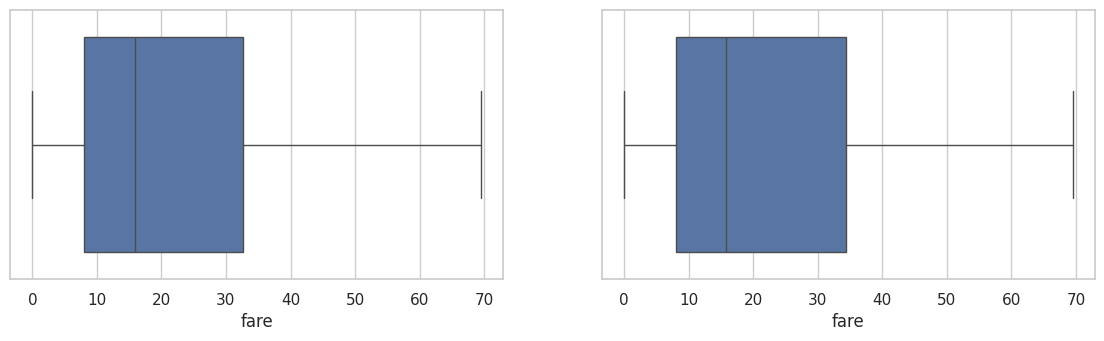

In [31]:
train_fare_clipped = Xtr["fare"].clip(lo, hi)
test_fare_clipped = Xte["fare"].clip(lo, hi)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
sns.boxplot(x=train_fare_clipped, ax=ax[0])
sns.boxplot(x=test_fare_clipped, ax=ax[1])
plt.show()